In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [71]:
state_by_month_cps = pd.read_csv('state_by_month_cps.csv')
state_by_month_cps['PERIOD'] = pd.to_datetime(state_by_month_cps['PERIOD']).dt.to_period('M')
state_by_month_cps

,Unnamed: 0,PERIOD,YEAR,MONTH,IND1990,EMPSTAT,ASECWT,WTFINL,DID_DUMMY,NJ_PA,POLICY_PERIOD
0,0,1988-01,1988,1,0,34,NaN,1241.0400,0,1,0
1,1,1988-01,1988,1,192,10,NaN,1537.2900,0,1,0
2,2,1988-01,1988,1,910,10,NaN,1266.4100,0,1,0
3,3,1988-01,1988,1,0,31,NaN,1288.7100,0,1,0
4,4,1988-01,1988,1,0,0,NaN,1212.1600,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
1519211,1519211,1997-12,1997,12,0,36,NaN,1892.5032,0,0,1
1519212,1519212,1997-12,1997,12,0,36,NaN,2317.6384,0,0,1
1519213,1519213,1997-12,1997,12,831,10,NaN,2039.9635,0,0,1
1519214,1519214,1997-12,1997,12,60,10,NaN,2142.6876,0,0,1


In [72]:
# Filtering for CPS data points with following criterias:
# Working in 641 (eating and drinkiing places)
# Working (EMPSTAT = 10) or has job, hasn't worked in past week (EMPSTAT = 12)
state_by_month_cps = state_by_month_cps[(state_by_month_cps['ASECWT'].isna() == True) & (state_by_month_cps['IND1990'] == 641) & (state_by_month_cps['EMPSTAT'] >= 10) & (state_by_month_cps['EMPSTAT'] <= 12)].reset_index()
# Aggregating to group weights of individuals for each period that met filtering criteria
state_by_month_cps_sum = state_by_month_cps.groupby(['NJ_PA', 'PERIOD'])['WTFINL'].sum().reset_index()
state_by_month_cps_sum

,NJ_PA,PERIOD,WTFINL
0,0,1988-01,233245.2700
1,0,1988-02,206743.6300
2,0,1988-03,218862.5700
3,0,1988-04,243557.3800
4,0,1988-05,292737.9400
...,...,...,...
235,1,1997-08,195959.2994
236,1,1997-09,170358.7339
237,1,1997-10,179518.6538
238,1,1997-11,164377.2749


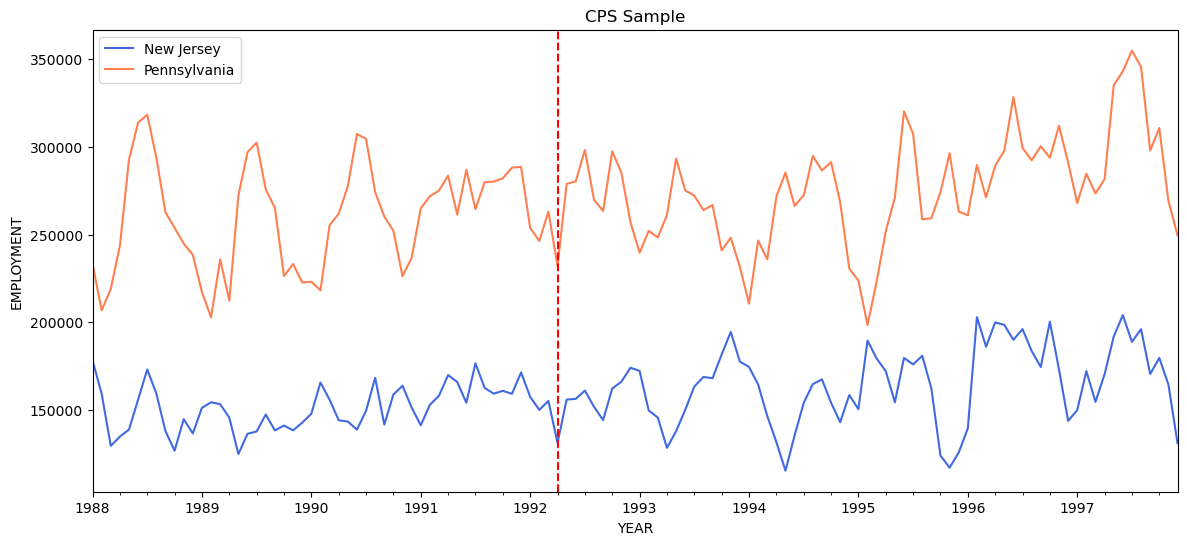

In [73]:
#Creating graph for employment totals at a state x monthly period for New Jersey and Pennsylvania
fig, ax = plt.subplots(figsize=(14, 6))

nj_state_by_month_cps = state_by_month_cps_sum[state_by_month_cps_sum.get('NJ_PA') == 1].set_index('PERIOD')
pa_state_by_month_cps = state_by_month_cps_sum[state_by_month_cps_sum.get('NJ_PA') == 0].set_index('PERIOD')

nj_state_by_month_cps.plot(kind='line', y='WTFINL', ax=ax, label = 'New Jersey', color ='royalblue');
pa_state_by_month_cps.plot(kind='line', y='WTFINL', ax=ax, label='Pennsylvania', color='coral');

period = pd.Period('1992-04', freq = 'M');
ax.axvline(x=period, color='red', linestyle='--', label='Vertical Line');
plt.xlabel('YEAR')
plt.ylabel('EMPLOYMENT')
ax.set_title('CPS Sample');
fig.savefig('/Users/chrisgee/UCSD2526/replication_project/output/CPS_641_EMPLOYMENT_1988_1998', dpi=300, bbox_inches='tight')

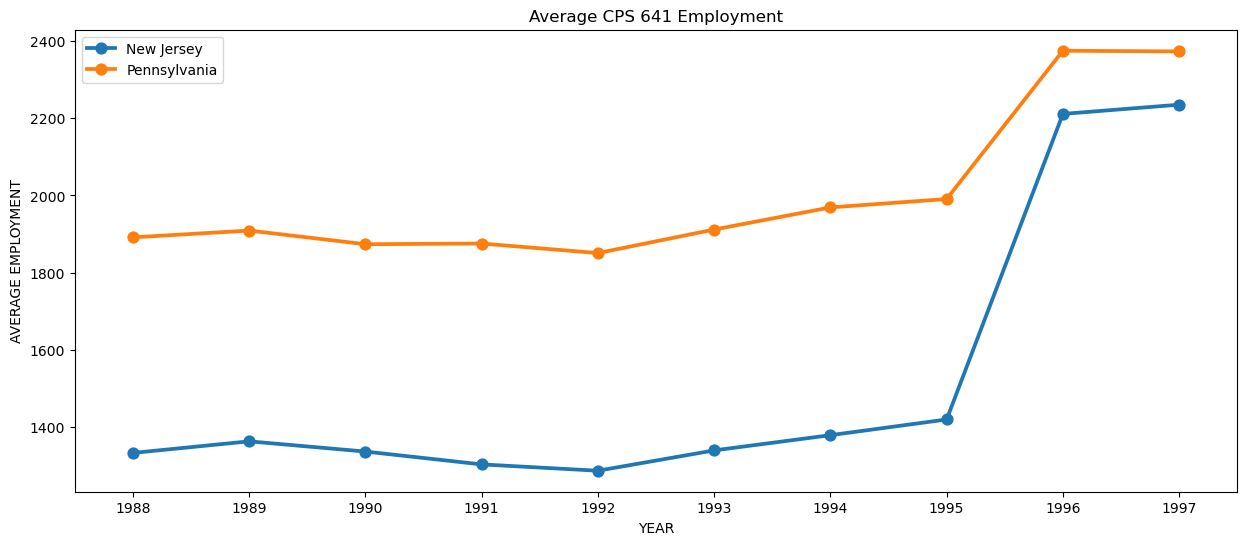

In [74]:
# Setting up dataframe for average employment per year
state_by_month_cps_avg = state_by_month_cps.groupby(['NJ_PA', 'YEAR'])[['WTFINL']].mean().reset_index()

# Creating pointplot for average employment per year for New Jersey and Pennsylvania
fig, ax = plt.subplots(figsize=(15,6))


nj_state_by_month_cps_avg = state_by_month_cps_avg[state_by_month_cps_avg.get('NJ_PA') == 1]
pa_state_by_month_cps_avg = state_by_month_cps_avg[state_by_month_cps_avg.get('NJ_PA') == 0]

sns.pointplot(
    data=nj_state_by_month_cps_avg,
    x='YEAR',
    y='WTFINL',
    ax=ax,
    label='New Jersey'
)

sns.pointplot(
    data=pa_state_by_month_cps_avg,
    x='YEAR',
    y='WTFINL',
    ax=ax,
    label='Pennsylvania'
)
ax.set_title('Average CPS 641 Employment')
plt.ylabel('AVERAGE EMPLOYMENT')
plt.xlabel('YEAR')
fig.savefig('/Users/chrisgee/UCSD2526/replication_project/output/CPS_641_AVG_EMPLOYMENT_1988_1998', dpi=300, bbox_inches='tight')